In [1]:
import pycbc
import copy
import json
import numpy as np
import pycbc.types
from pycbc.types import MultiDetOptionAction
import pycbc.psd
import pycbc.filter
from pycbc.psd.lisa_pre_merger import generate_pre_merger_psds

from pycbc.waveform.pre_merger_waveform import (
    pre_process_data_lisa_pre_merger,
    generate_waveform_lisa_pre_merger,
)

import inpainting_utils

from matplotlib import pyplot as plt

/opt/homebrew/Caskroom/miniconda/base/envs/pycbc_test_py312/lib/python3.12/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
/opt/homebrew/Caskroom/miniconda/base/envs/pycbc_test_py312/lib/python3.12/site-packages/pykerr/qnm.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain

No CuPy
No CuPy or GPU PhenomHM module.
No CuPy or GPU response available.
No CuPy or GPU interpolation available.


## Top level settings

You change some of these things, some might work, some might not.

In [2]:
psdname = 'optimistic'
signumber = '0'
data_length = 2592000
zeroed_length = 2**20 # Data length is not the same for zero-latency vs inpainting as we add extra zeroes to inpainting
sample_rate = 0.2
flen = int(zeroed_length) // 2 + 1
delta_f = 1 / (2**20 * 5) # Delta_f is not the same for zero-latency vs inpainting as we add extra zeroes to inpainting
delta_t = 1 / sample_rate
time_before = 86400*7


### Zero-latency filter

The following cell computes the SNR using the zero-latency filter approach. This requires code from our premerger paper
https://icg-gravwaves.github.io/lisa_premerger_paper/README.html to run ... Everything else should run off of "standard" installs

This is done to assist making comparison plots later.


In [3]:
## Get the zero-latency SNR series
waveform_params_shared = {
    't_obs_start': data_length, # This is setting the data length.
    'f_lower': 0.000001,
    'low-frequency-cutoff': 0.000001, 
    'f_final': 0.2 / 2,
    'delta_f': 1 / data_length,
    'tdi': '1.5',
    't_offset': 0,
    'cutoff_deltat': 0,
}

data = pycbc.types.timeseries.load_timeseries(
        f'../../datasets/signal_0.hdf',
        group=f"/LISA_A",
)
data._delta_t = 5 # Apparently it is not exactly this in the file, causing issues.


with open('../../datasets/injections.json', 'r') as inj_file:
    injections = json.load(inj_file)

waveform_params = injections['0']
waveform_params.update(waveform_params_shared)


lisa_a_zero_phase_kern = generate_pre_merger_psds(
    psd_file=f'../../datasets/model_AE_TDI1_SMOOTH_optimistic.txt.gz',
    duration=data_length,
    sample_rate=sample_rate,
    kernel_length=17280
)

psds_for_whitening = {'LISA_A': lisa_a_zero_phase_kern['FD'], 'LISA_E': lisa_a_zero_phase_kern['FD']}

cutoff_time=time_before
search_time=86400
window_length=17280

filter_waveform = copy.deepcopy(waveform_params)
filter_waveform.update({
    'approximant': 'BBHX_PhenomD',
    'mode_array':[(2,2)],
    't_offset': 7365189.431698299,
})

data_dict = {}
data_dict['LISA_A'] = data
data_dict['LISA_E'] = data
data_dict = pre_process_data_lisa_pre_merger(
        data_dict,
        sample_rate=sample_rate,
        psds_for_whitening=psds_for_whitening,
        window_length=window_length,
        cutoff_time=cutoff_time,
        forward_zeroes=17280,
)
data_f_dict = {}
data_f_dict['LISA_A'] = data_dict['LISA_A'].to_frequencyseries()
data_f_dict['LISA_E'] = data_dict['LISA_A'].to_frequencyseries()


waveforms = generate_waveform_lisa_pre_merger(
        filter_waveform,
        psds_for_whitening,
        sample_rate=sample_rate,
        window_length=window_length,
        cutoff_time=cutoff_time,
        forward_zeroes=17280,
)

snrA = pycbc.filter.matched_filter(
        waveforms['LISA_A'],
        data_f_dict['LISA_A'],
)


/opt/homebrew/Caskroom/miniconda/base/envs/pycbc_test_py312/lib/python3.12/site-packages/BBHX_Phenom.py:287: RuntimeWarning: Input 'f_lower' is lower than the value calculated from 't_obs_start'.
  warn(err_msg, RuntimeWarning)


## Inpainting

Now let's do the same with inpainting.

In [4]:
# Set up waveform_params
waveform_params_shared = {
    't_obs_start': data_length, # This is setting the length of the signal
    'f_lower': 0.000001,
    'low-frequency-cutoff': 0.000001, 
    'f_final': 0.2 / 2,
    'delta_f': 1 / data_length,
    'tdi': '1.5',
    't_offset': 0,
    'cutoff_deltat': 0,
}

with open('../../datasets/injections.json', 'r') as inj_file:
    injections = json.load(inj_file)

waveform_params = injections['0']
waveform_params.update(waveform_params_shared)
filter_waveform = copy.deepcopy(waveform_params)
filter_waveform.update({
    'approximant': 'BBHX_PhenomD',
    'mode_array':[(2,2)],
    't_offset': 7365189.431698299,
})

# Not using generate_lisa_pre_merger_psds_inpaint as not needed
psd = pycbc.psd.from_txt(
    f'../../datasets/model_AE_TDI1_SMOOTH_optimistic.txt.gz',
    flen,
    delta_f,
    delta_f,
    is_asd_file=False
)

strain_dict = inpainting_utils.generate_data_lisa_pre_merger_inpaint(
    filter_waveform,
    {'LISA_A': psd, 'LISA_E': psd},
    zeroed_length,
    sample_rate,
    seed=213,
    zero_noise=False,
    no_signal=False,
)

data_ow_fd = inpainting_utils.pre_process_data_lisa_pre_merger_inpaint(
    strain_dict,
    sample_rate,
    {'LISA_A': psd, 'LISA_E': psd},
    inpaint_start=int((data_length - time_before) * sample_rate),
    inpaint_end=int(data_length*sample_rate) + 10 # 10 samples added for safety at end
)

# Changing waveform length now in this bit to match longer length
filter_waveform['t_obs_start'] = int(zeroed_length / sample_rate + 0.5)
filter_waveform['delta_f'] = delta_f
filter_waveform['f_final'] = filter_waveform['f_final'] + delta_f / 2 # This is a hack to ensure we get the point at f_final returned


# We'll assume the output of this has the merger at the end!
waveforms = inpainting_utils.generate_waveform_lisa_pre_merger_inpaint(
    filter_waveform,
    {'LISA_A': psd, 'LISA_E': psd},
    sample_rate,
) 

# NEW THING: Need time-dependent (h|h).
for channel in waveforms:
    mask = pycbc.types.TimeSeries(
        np.ones(zeroed_length, dtype=strain_dict[channel].dtype),
        delta_t=delta_t,
        epoch=strain_dict[channel]._epoch
    )
    mask[int((data_length - time_before) * sample_rate):] = 0 # All points after inpaint_start are zeroed in the mask
    # PLEASE NOTE, GAPS WOULD BE ADDED HERE INTO THE MASK
    invpsd = 1./psd # Here is the same for both ifos, but might be different normally
    invpsd[0] = 0 # Don't forget this!!!
    maskfs = mask.to_frequencyseries()
    waveform = (waveforms[channel].to_frequencyseries() * invpsd**0.5).to_timeseries()
    waveform_sq = waveform * waveform
    masked_waveform_sq_fs = maskfs * waveform_sq.to_frequencyseries().conj() 
    masked_waveform_sq_ts = masked_waveform_sq_fs.to_timeseries() # This is what holds (h|h)(t)

# Now we can matched-filter
snrs = {}
for channel in waveforms:
    snr = pycbc.filter.matched_filter(
            waveforms[channel],
            data_ow_fd[channel],
            sigmasq=1,
    )
    snr = snr / masked_waveform_sq_ts**0.5 / 2**0.5 # Not really sure where the factor of 2 comes from, but it is needed
    snrs[channel] = snr



/opt/homebrew/Caskroom/miniconda/base/envs/pycbc_test_py312/lib/python3.12/site-packages/pycbc/types/array.py:390: RuntimeWarning: divide by zero encountered in divide
  return self._data.__rtruediv__(other)


/opt/homebrew/Caskroom/miniconda/base/envs/pycbc_test_py312/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/homebrew/Caskroom/miniconda/base/envs/pycbc_test_py312/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


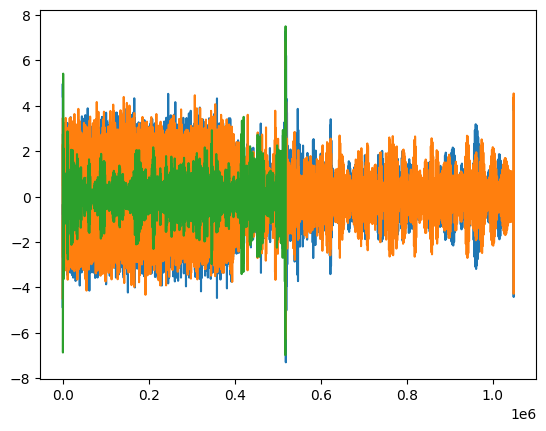

In [5]:
for channel in waveforms:
    plt.plot(snrs[channel])

plt.plot(snrA)

# The zero latency filter *should* produce a shorter SNR series than the new method, and should only agree at X-days premerger where
# the cut it.

(508116.0, 528116.0)

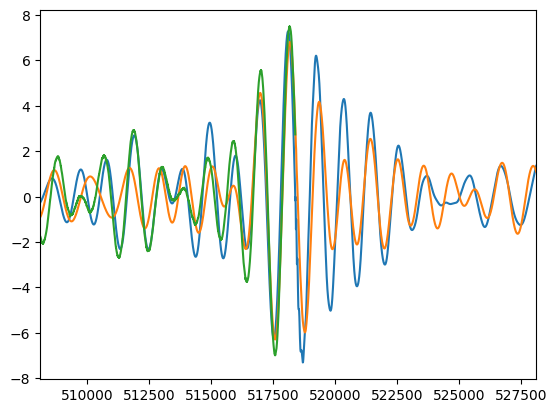

In [8]:
for channel in waveforms:
    plt.plot(snrs[channel])

plt.plot(snrA)
plt.xlim([518116-10000,518116+10000]) # ZOom on peak

# Note this comparison is not as good as the one in my other notebook.
# The data being generated is not the same here, so we expect divergence.


In [6]:
print(abs(snrA.data).argmax())

518116


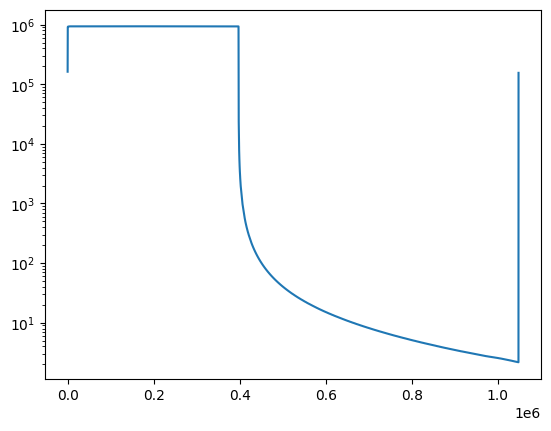

In [28]:
plt.semilogy(masked_waveform_sq_ts)

In [ ]:
"""
def generate_lisa_pre_merger_psds_inpaint(
    psd_file,
    duration,
    sample_rate,
    kernel_length=17280, # REMOVED KERNEL LENGTH AS UNUSED
):

# REMOVED TD PSD AS NOT NEEDED
# THIS REALLY DOESN'T NEED A SEPARATE FUNCTION!

def generate_data_lisa_pre_merger_inpaint(
    waveform_params,
    psds_for_datagen,
    sample_rate,
    seed=137,
    zero_noise=False,
    no_signal=False,
):

# Added 0s on the end!
# REmoved the duration kwarg


def generate_waveform_lisa_pre_merger_inpaint(
        waveform_params,
        psds_for_whitening,
        sample_rate=0.2,
        **kwargs
):

# Removed unused kwargs

def pre_process_data_lisa_pre_merger_inpaint(
    data_timeseries,
    sample_rate,
    psds_for_whitening,
    window_length=None,
    cutoff_time=None,
    **kwargs
):

# Removed unused window and window_length
# Removed unused kwargs
"""
